# Day 12: Neural Networks and Deep Learning Foundations

## Forward Pass, Gradient Descent, TensorFlow/Keras, and Training Curves

This notebook introduces the mathematical and practical foundation of neural networks.

Students will learn:

- What a single artificial neuron does
- Dot product, weights, bias, and activation
- ReLU activation
- Gradient descent intuition
- Learning rate
- TensorFlow and Keras model creation
- Dense neural networks
- Binary classification
- Loss function and optimizer
- Training and validation curves
- Model evaluation

The teaching flow is:

```text
One neuron manually → Gradient descent manually → Build neural network with Keras → Train and evaluate
```

---

# Instructor Setup Note

In Google Colab, TensorFlow is usually pre-installed.

If students get an import error, run:

```python
!pip install tensorflow
```

This notebook uses a small synthetic dataset, so it should run quickly on CPU.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Day 12 Deep Learning Environment Initialized.")
np.random.seed(42)

Day 12 Deep Learning Environment Initialized.


---

# 1. The Mathematical Forward Pass

## Explanation

Before using Keras, we should understand what one neural network node does internally.

A single artificial neuron performs two main steps.

## Step 1: Linear Combination

```text
z = w1*x1 + w2*x2 + w3*x3 + b
```

Where:

| Symbol | Meaning |
|---|---|
| `x` | Input value |
| `w` | Weight |
| `b` | Bias |
| `z` | Linear output |

In this example:

- Vision Score = 98
- Text Score = 85
- Attendance = 92

The neuron multiplies each input by a weight, adds them, and then adds a bias.

## Step 2: Activation Function

The activation function decides what signal should move forward.

Here we use ReLU.

```text
ReLU(x) = max(0, x)
```

ReLU turns negative values into 0 and keeps positive values unchanged.

In [2]:
import numpy as np

inputs = np.array([98.0, 85.0, 92.0])

weights = np.array([0.2, 0.5, -0.1])
bias = 0.5

z = np.dot(inputs, weights) + bias
print(f"Linear Output (z): {z:.2f}")

def relu(x):
    return np.maximum(0, x)

activation_output = relu(z)
print(f"Node Output after ReLU: {activation_output:.2f}")

Linear Output (z): 53.40
Node Output after ReLU: 53.40


## Extra Cell 1: Breaking Down the Dot Product

Students often understand better when the dot product is shown step by step.

Each input is multiplied by its matching weight.

In [3]:
products = inputs * weights

for i, (x, w, product) in enumerate(zip(inputs, weights, products), start=1):
    print(f"x{i} = {x:.1f}, w{i} = {w:.1f}, x{i}*w{i} = {product:.2f}")

print(f"Sum of weighted inputs: {np.sum(products):.2f}")
print(f"Bias added: {bias:.2f}")
print(f"Final z: {z:.2f}")

x1 = 98.0, w1 = 0.2, x1*w1 = 19.60
x2 = 85.0, w2 = 0.5, x2*w2 = 42.50
x3 = 92.0, w3 = -0.1, x3*w3 = -9.20
Sum of weighted inputs: 52.90
Bias added: 0.50
Final z: 53.40


## Extra Cell 2: ReLU Visualization

ReLU is one of the most common activation functions in deep learning.

Negative values become 0.

Positive values remain unchanged.

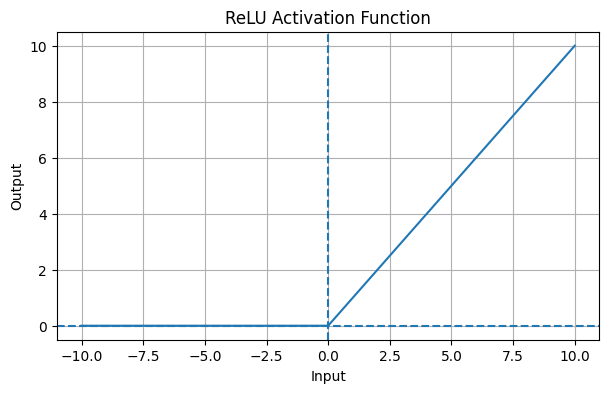

In [16]:
x_relu = np.linspace(-10, 10, 200)
y_relu = relu(x_relu)

plt.figure(figsize=(7, 4))
plt.plot(x_relu, y_relu)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

---

# 2. Simulating Gradient Descent

## Explanation

Training a neural network means finding good weights.

But how does the model know how to change the weights?

It uses gradient descent.

Gradient descent tries to minimize the loss.

In this simplified example, the loss function is:

```text
loss = x²
```

The minimum is at:

```text
x = 0
```

The gradient tells us the direction of steepest increase.

To reduce loss, we move in the opposite direction of the gradient.

The update rule is:

```text
new_weight = current_weight - learning_rate * gradient
```

The learning rate controls step size.

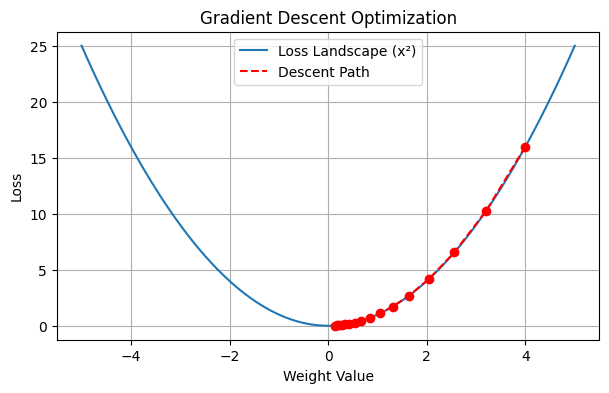

In [5]:
import matplotlib.pyplot as plt

def loss_function(x):
    return x**2

def gradient(x):
    return 2*x

learning_rate = 0.1
current_weight = 4.0
history = [current_weight]

for i in range(15):
    grad = gradient(current_weight)
    current_weight = current_weight - (learning_rate * grad)
    history.append(current_weight)

x_vals = np.linspace(-5, 5, 100)

plt.figure(figsize=(7, 4))
plt.plot(x_vals, loss_function(x_vals), label="Loss Landscape (x²)")
plt.scatter(history, loss_function(np.array(history)), color="red", zorder=5)
plt.plot(history, loss_function(np.array(history)), color="red", linestyle="--", label="Descent Path")
plt.title("Gradient Descent Optimization")
plt.xlabel("Weight Value")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Extra Cell 3: Print Gradient Descent Steps

This table shows how the weight moves closer to the minimum after every update.

In [6]:
current_weight = 4.0
learning_rate = 0.1

print("Step | Weight | Gradient | Loss")
print("-" * 35)

for step in range(10):
    grad = gradient(current_weight)
    loss = loss_function(current_weight)
    print(f"{step:>4} | {current_weight:>6.3f} | {grad:>8.3f} | {loss:>6.3f}")
    current_weight = current_weight - learning_rate * grad

Step | Weight | Gradient | Loss
-----------------------------------
   0 |  4.000 |    8.000 | 16.000
   1 |  3.200 |    6.400 | 10.240
   2 |  2.560 |    5.120 |  6.554
   3 |  2.048 |    4.096 |  4.194
   4 |  1.638 |    3.277 |  2.684
   5 |  1.311 |    2.621 |  1.718
   6 |  1.049 |    2.097 |  1.100
   7 |  0.839 |    1.678 |  0.704
   8 |  0.671 |    1.342 |  0.450
   9 |  0.537 |    1.074 |  0.288


## Extra Cell 4: Learning Rate Comparison

Learning rate is one of the most important hyperparameters.

If learning rate is too small, training is slow.

If learning rate is too large, the model may overshoot the minimum.

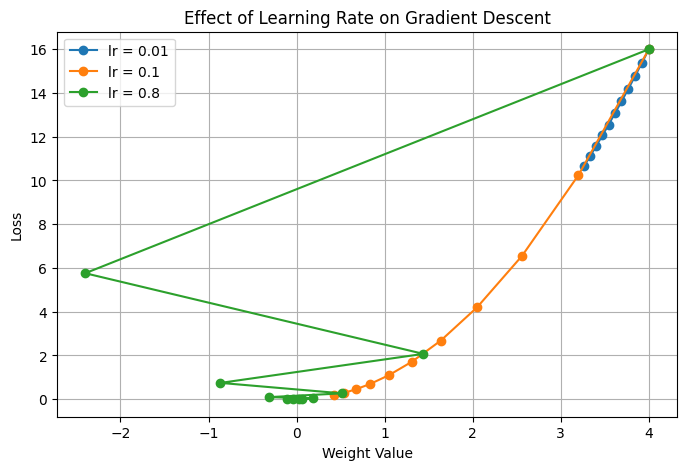

In [7]:
learning_rates = [0.01, 0.1, 0.8]
start_weight = 4.0

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    weight = start_weight
    path = [weight]

    for _ in range(10):
        weight = weight - lr * gradient(weight)
        path.append(weight)

    path = np.array(path)
    plt.plot(path, loss_function(path), marker="o", label=f"lr = {lr}")

plt.title("Effect of Learning Rate on Gradient Descent")
plt.xlabel("Weight Value")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

---

# 3. TensorFlow and Keras Initialization

## Explanation

Now we move from manual math to a real neural network library.

TensorFlow is a deep learning framework.

Keras is the high-level API used to build neural networks easily.

We will build a dense neural network for the MET AI Autograder.

The model predicts whether a student passes or fails based on four features:

- Vision score
- Text score
- Logic score
- Attendance

The target is binary:

| Target | Meaning |
|---|---|
| 0 | Fail |
| 1 | Pass |

Since the output is binary, the final layer uses a sigmoid activation.

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

X_data = np.random.uniform(0, 100, (123, 4))
y_data = (np.sum(X_data, axis=1) > 200).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

model = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,385 (9.32 KB)

 Trainable params: 2,385 (9.32 KB)

 Non-trainable params: 0 (0.00 B)

## How to Explain the Architecture

The network has:

| Layer | Meaning |
|---|---|
| Input shape `(4,)` | Four input features |
| Dense 16 | First hidden layer with 16 neurons |
| Dense 8 | Second hidden layer with 8 neurons |
| Dense 1 | Output layer |
| ReLU | Used in hidden layers |
| Sigmoid | Used for binary probability output |

The final sigmoid output is a probability between 0 and 1.

## Extra Cell 5: Inspect Dataset Shapes

Deep learning is very shape-sensitive.

Most errors in neural network code come from wrong input/output shapes.

In [23]:
print("X_data shape:", X_data.shape)
print("y_data shape:", y_data.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 3 input rows:")
print(np.round(X_data[:3], 2))

print("\nFirst 10 labels:")
print(y_data[:10])

X_data shape: (123, 4)
y_data shape: (123,)
X_train shape: (98, 4)
X_test shape: (25, 4)
y_train shape: (98,)
y_test shape: (25,)

First 3 input rows:
[[37.45 95.07 73.2  59.87]
 [15.6  15.6   5.81 86.62]
 [60.11 70.81  2.06 96.99]]

First 10 labels:
[1 0 1 0 0 0 0 0 1 0]


---

# 4. Compiling and Training

## Explanation

Before training, we must compile the model.

Compiling attaches three important things.

## 1. Optimizer

The optimizer updates the weights.

We use Adam, an adaptive version of gradient descent.

## 2. Loss Function

The loss function measures how wrong the model is.

For binary classification, we use:

```python
binary_crossentropy
```

## 3. Metrics

Metrics help us monitor performance.

Here we track accuracy.

After compiling, we train using:

```python
model.fit()
```

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Starting Training Loop...")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=0
)

print("Training Complete.")

Starting Training Loop...
Training Complete.


## Training Terms

| Term | Meaning |
|---|---|
| Epoch | One full pass through the training data |
| Batch size | Number of samples processed before updating weights |
| Validation data | Data used to check performance during training |
| Loss | Error value being minimized |
| Accuracy | Fraction of correct predictions |

---

# 5. Evaluating Network Performance

## Explanation

The `history` object stores training progress.

We can visualize:

- Training loss
- Validation loss
- Training accuracy
- Validation accuracy

This helps us understand whether the model is learning.

Good signs:

- Training loss decreases
- Validation loss decreases
- Accuracy increases

Warning signs:

- Training accuracy increases but validation accuracy stays low
- Training loss decreases but validation loss increases

That may indicate overfitting.

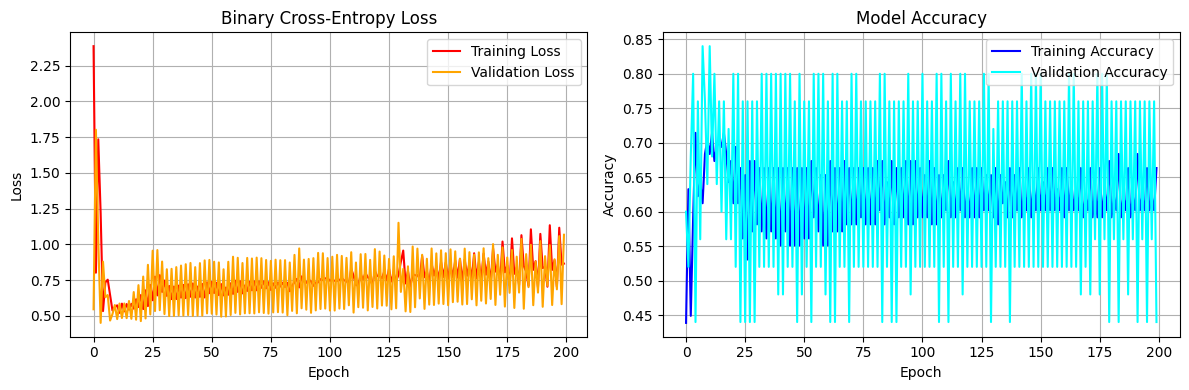

Final Test Accuracy: 44.00%


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="Training Loss", color="red")
ax1.plot(history.history["val_loss"], label="Validation Loss", color="orange")
ax1.set_title("Binary Cross-Entropy Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(history.history["accuracy"], label="Training Accuracy", color="blue")
ax2.plot(history.history["val_accuracy"], label="Validation Accuracy", color="cyan")
ax2.set_title("Model Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

# Heart Disease Prediction Using Artificial Neural Networks (ANN)
## Objective
Build a Binary Classification Neural Network using Keras Sequential API to predict whether a patient has heart disease based on clinical and medical attributes.
---
# Task 1: Load the Dataset
Load the Kaggle Heart Disease Dataset into a Pandas DataFrame.
### Requirements
- Read the CSV file using Pandas.
- Display:
  - First 5 rows
  - Dataset shape
  - Data types
  - Summary statistics
### Expected Outcome
Understand the structure of the dataset and identify the target variable.
---
# Task 2: Perform Basic Data Preprocessing
Prepare the dataset for training.
### Requirements
- Check for missing values.
- Remove or handle null values if present.
- Separate:
  - Features (X)
  - Target Variable (y)
- Verify class distribution.
### Expected Outcome
A clean dataset ready for machine learning.
---
# Task 3: Split the Dataset
Split the dataset into training and testing sets.
### Requirements
Use:
```python
train_test_split()
```
Parameters:
```python
test_size = 0.20
random_state = 42
```
### Split Ratio
| Dataset Portion | Percentage |
|----------------|------------|
| Training Set | 80% |
| Testing Set | 20% |
### Expected Outcome
- X_train
- X_test
- y_train
- y_test
---
# Task 4: Feature Standardization
Scale all numerical features using StandardScaler.
### Requirements
Use:
```python
from sklearn.preprocessing import StandardScaler
```
Apply:
```python
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
```
### Why?
Neural Networks perform better when features are on a similar scale.
### Expected Outcome
All features should have approximately:
```text
Mean ≈ 0
Standard Deviation ≈ 1
```
---
# Task 5: Build the Neural Network
Create a Sequential Neural Network using Dense Layers.
## Architecture
### Input Layer
Number of neurons:
```python
input_shape=(X_train.shape[1],)
```
### Hidden Layer 1
```python
Dense(64, activation='relu')
```
### Hidden Layer 2
```python
Dense(32, activation='relu')
```
### Hidden Layer 3
```python
Dense(16, activation='relu')
```
### Output Layer
```python
Dense(1, activation='sigmoid')
```
---
## Model Architecture Summary
| Layer | Neurons | Activation |
|---------|---------|------------|
| Hidden Layer 1 | 64 | ReLU |
| Hidden Layer 2 | 32 | ReLU |
| Hidden Layer 3 | 16 | ReLU |
| Output Layer | 1 | Sigmoid |
---
# Task 6: Compile the Model
Configure the training process.
### Optimizer
```python
Adam
```
### Loss Function
```python
Binary Crossentropy
```
### Metric
```python
Accuracy
```
### Compilation
```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```
---
# Task 7: Train the Neural Network
Train the model using the training dataset.
### Parameters
| Parameter | Value |
|------------|--------|
| Epochs | 100 |
| Batch Size | 16 |
| Validation Split | 20% |
### Training Code
```python
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)
```
### Expected Outcome
The model should learn patterns that distinguish patients with and without heart disease.
---
# Task 8: Plot Training Performance
## A. Loss Curve
Plot:
- Training Loss
- Validation Loss
### Graph Title
```text
Training vs Validation Loss
```
### X-axis
```text
Epochs
```
### Y-axis
```text
Loss
```
---
## B. Accuracy Curve
Plot:
- Training Accuracy
- Validation Accuracy
### Graph Title
```text
Training vs Validation Accuracy
```
### X-axis
```text
Epochs
```
### Y-axis
```text
Accuracy
```
---
# Task 9: Evaluate the Model
Evaluate performance using the testing dataset.
### Requirements
Calculate:
```python
test_loss
test_accuracy
```
### Display
```text
Test Accuracy: XX.XX%
```
---
# Task 10: Generate Predictions
Predict whether each patient has heart disease.
### Convert Probabilities into Classes
Rule:
```python
If probability > 0.5 → Heart Disease
Else → No Heart Disease
```
---
# Task 11: Confusion Matrix
Generate and visualize a confusion matrix.
### Display
| Actual / Predicted | No Disease | Disease |
|-------------------|------------|----------|
| No Disease | TN | FP |
| Disease | FN | TP |
### Graph Title
```text
Confusion Matrix
```
---
# Task 12: Classification Report
Generate:
```python
classification_report()
```
### Metrics to Report
- Precision
- Recall
- F1-Score
- Support
### Expected Output
```text
              precision    recall    f1-score
No Disease
Disease
accuracy
macro avg
weighted avg
```
---
# Deliverables
Submit:
### 1. Source Code
- Complete ANN implementation
### 2. Dataset Description
- Features
- Target Variable
### 3. Model Architecture
- Sequential Model
- Dense Layers
### 4. Training Results
- Final Training Accuracy
- Final Validation Accuracy
### 5. Visualizations
- Loss Graph
- Accuracy Graph
- Confusion Matrix
### 6. Evaluation Metrics
- Test Accuracy
- Precision
- Recall
- F1-Score
### 7. Conclusion
Write a short summary answering:
1. How well did the model perform?
2. Was overfitting observed?
3. What could improve the model further?
---
# ANN Configuration Summary
| Hyperparameter | Value |
|----------------|--------|
| Model Type | Sequential ANN |
| Hidden Layers | 3 |
| Neurons | 64 → 32 → 16 |
| Activation | ReLU |
| Output Activation | Sigmoid |
| Optimizer | Adam |
| Loss Function | Binary Crossentropy |
| Metric | Accuracy |
| Train-Test Split | 80:20 |
| Epochs | 100 |
| Batch Size | 16 |
| Validation Split | 20% |


## Extra Cell 6: Predicting with the Neural Network

The model outputs probabilities.

We convert probabilities into class labels using a threshold.

Common rule:

```text
Probability >= 0.5 → Pass
Probability < 0.5 → Fail
```

In [12]:
y_prob = model.predict(X_test, verbose=0)
y_pred = (y_prob >= 0.5).astype(int).flatten()

print("First 10 predicted probabilities:")
print(np.round(y_prob[:10].flatten(), 4))

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

First 10 predicted probabilities:
[0.e+00 0.e+00 1.e-04 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 3.e-04]

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 actual labels:
[1 1 0 1 0 1 1 1 1 0]


## Extra Cell 7: Confusion Matrix

Accuracy is useful, but it does not show the exact types of mistakes.

A confusion matrix shows:

- Correct fail predictions
- Correct pass predictions
- False pass predictions
- False fail predictions

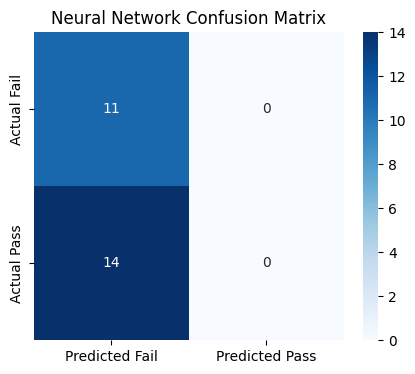

              precision    recall  f1-score   support

        Fail       0.44      1.00      0.61        11
        Pass       0.00      0.00      0.00        14

    accuracy                           0.44        25
   macro avg       0.22      0.50      0.31        25
weighted avg       0.19      0.44      0.27        25



/Users/sai/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sai/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sai/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="g",
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"]
)
plt.title("Neural Network Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

## Extra Cell 8: Predict a New Student

Now we can give the model a new student's features and ask for a prediction.

Feature order:

```text
Vision, Text, Logic, Attendance
```

In [14]:
new_student = np.array([[85, 78, 90, 88]])

new_probability = model.predict(new_student, verbose=0)[0][0]
new_class = int(new_probability >= 0.5)

print("New student features: Vision=85, Text=78, Logic=90, Attendance=88")
print(f"Predicted Pass Probability: {new_probability:.4f}")
print("Prediction:", "Pass" if new_class == 1 else "Fail")

New student features: Vision=85, Text=78, Logic=90, Attendance=88
Predicted Pass Probability: 0.0000
Prediction: Fail


---

# Extra Cell 9: Why Scaling Matters

Neural networks often train better when input features are scaled.

Here our features are between 0 and 100.

We can scale them between 0 and 1 by dividing by 100.

For this simple dataset, the model may still work without scaling.

But in real deep learning, scaling is very important.

In [15]:
X_scaled = X_data / 100.0

print("Original first row:")
print(np.round(X_data[0], 2))

print("\nScaled first row:")
print(np.round(X_scaled[0], 4))

Original first row:
[37.45 95.07 73.2  59.87]

Scaled first row:
[0.3745 0.9507 0.732  0.5987]


---

# Day 12 Hands-On Coding Test

The following problems are for students to solve independently.

No solutions are provided in this test section.

# Test 1: Easy  
## Manual Forward Pass

### Concepts Tested

- NumPy arrays
- Dot product
- Bias
- ReLU activation

## Problem Statement

You are given:

```python
inputs = np.array([70.0, 80.0, 90.0])
weights = np.array([0.3, 0.4, 0.2])
bias = 1.0
```

Write Python code to:

1. Calculate the linear output `z`
2. Define a ReLU function
3. Calculate the ReLU output
4. Print both `z` and the activation output

In [ ]:
# Test 1 Student Code

import numpy as np

inputs = np.array([70.0, 80.0, 90.0])
weights = np.array([0.3, 0.4, 0.2])
bias = 1.0

# Write your solution here

---

# Test 2: Medium  
## Gradient Descent Simulation

### Concepts Tested

- Loss function
- Gradient
- Learning rate
- Loop
- Weight update

## Problem Statement

Use the loss function:

```python
loss = x**2
```

and gradient:

```python
gradient = 2*x
```

Start with:

```python
current_weight = -3.0
learning_rate = 0.2
```

Write Python code to:

1. Run gradient descent for 12 iterations
2. Store each weight value in a list called `history`
3. Print the final weight
4. Plot the loss curve and the descent path

In [ ]:
# Test 2 Student Code

import numpy as np
import matplotlib.pyplot as plt

current_weight = -3.0
learning_rate = 0.2

# Write your solution here

---

# Test 3: Hard  
## Build and Train a Keras Neural Network

### Concepts Tested

- Synthetic dataset
- Train-test split
- Sequential model
- Dense layers
- Compile
- Fit
- Evaluate

## Problem Statement

Create a neural network to predict pass/fail.

Use:

```python
np.random.seed(10)
X = np.random.uniform(0, 100, (200, 3))
y = (X[:, 0] * 0.5 + X[:, 1] * 0.3 + X[:, 2] * 0.2 > 70).astype(int)
```

Write Python code to:

1. Split data into training and testing sets using `test_size=0.2` and `random_state=42`
2. Build a Keras Sequential model with:
   - Dense layer with 12 neurons and ReLU
   - Dense layer with 6 neurons and ReLU
   - Dense output layer with 1 neuron and sigmoid
3. Compile with Adam optimizer and binary cross-entropy loss
4. Train for 40 epochs with batch size 16
5. Plot training loss and validation loss
6. Evaluate the model on the test set
7. Print final test accuracy

In [ ]:
# Test 3 Student Code

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

np.random.seed(10)
tf.random.set_seed(10)

X = np.random.uniform(0, 100, (200, 3))
y = (X[:, 0] * 0.5 + X[:, 1] * 0.3 + X[:, 2] * 0.2 > 70).astype(int)

# Write your solution here

---

# End of Day 12 Notebook

By the end of this notebook, students should understand:

- What a neural node computes internally
- How weights, inputs, and bias combine into a linear output
- Why activation functions are needed
- How ReLU works
- How gradient descent updates weights
- Why learning rate matters
- How to build a neural network using Keras
- What Dense layers are
- Why sigmoid is used for binary classification
- How to compile and train a model
- How to read loss and accuracy curves
- How to evaluate predictions using a confusion matrix

This notebook prepares students for deeper topics like backpropagation, CNNs, RNNs, transformers, and real deep learning projects.